In [1]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import plot_helper as helper

# load data

In [2]:
base_outputs = [
    f"../output/layer{layer_id}"
    for layer_id in range(13)
]

In [3]:
model_names = ['EYE', 'RANDOM0', 'LC', 'LDA', 'PCA', 'COV', 'LEACE']
found_modes = ["clean"] #, "other", "all"]
label_names = ["spk", "phone"]
seeds = [0]
target_method = "LEACE"

In [4]:
formatted_scores = {
    "concept": [],
    "layer" : [],
    "retention": [],
    "leakage": [],
    "purity" : [],
    "interference": []
}
for base_output in base_outputs:
    concept = []
    method = []
    mode = []
    seed = []
    retention = []
    purity = []
    leakage = []
    interference = []
    layer = []
    layer_id = base_output.split("layer")[-1]
    
    for mode_ in found_modes:
        # handle cases when dev-all (dev-clean + dev-other) is used for training classifier
        # we select (test-clean) as the test set
        mode_test_ = mode_ if mode_ != "all" else "clean"
        
        for model_ in model_names:
            for lab_1, lab_2 in zip(label_names, reversed(label_names)):
                    
                for seed_ in seeds:
                    concept.append(lab_1)
                    mode.append(mode_)
                    seed.append(seed_)
                    method.append(model_)
                    layer.append(layer_id)
                    if model_ == "EYE":
                        file_ = os.path.join(base_output, f"{model_}_{mode_}", "projection", f"dev-{mode_}-{lab_1}.csv")
                    elif model_.startswith("ITER"):
                        file_ = os.path.join(base_output, f"{model_}_all_{mode_}", "projection", f"dev-{mode_}-{lab_1}.csv")
                    else:
                        file_ = os.path.join(base_output, f"{model_}_{lab_1}_{mode_}", "projection", f"dev-{mode_}-{lab_1}.csv")
                    print(f"retention for {lab_1}", file_)
                    score_df = pd.read_csv(file_)
                    score = score_df[score_df["clf_train_data"] == f"dev-{mode_}"][f"test-{mode_test_}"].to_list()                
                    assert len(score) == 1
                    retention.append(score[0])
    
                    if model_ == "EYE":
                        file_ = os.path.join(base_output, f"{model_}_{mode_}", "rejection", f"dev-{mode_}-{lab_1}.csv")
                    elif model_.startswith("ITER"):
                        file_ = os.path.join(base_output, f"{model_}_all_{mode_}", "rejection", f"dev-{mode_}-{lab_1}.csv")
                    else:
                        file_ = os.path.join(base_output, f"{model_}_{lab_1}_{mode_}", "rejection", f"dev-{mode_}-{lab_1}.csv")
                    print(f"leakage for {lab_1}", file_)
                    score_df = pd.read_csv(file_)
                    score = score_df[score_df["clf_train_data"] == f"dev-{mode_}"][f"test-{mode_test_}"].to_list()                
                    assert len(score) == 1
                    leakage.append(score[0])
                    
                    if model_ == "EYE":    
                        file_ = os.path.join(base_output, f"{model_}_{mode_}", "projection", f"dev-{mode_}-{lab_2}.csv")
                    elif model_.startswith("ITER"):
                        file_ = os.path.join(base_output, f"{model_}_all_{mode_}", "projection", f"dev-{mode_}-{lab_2}.csv")
                    else:    
                        file_ = os.path.join(base_output, f"{model_}_{lab_1}_{mode_}", "projection", f"dev-{mode_}-{lab_2}.csv")
                    print(f"purity for {lab_1}", file_)
                    score_df = pd.read_csv(file_)
                    score = score_df[score_df["clf_train_data"] == f"dev-{mode_}"][f"test-{mode_test_}"].to_list()                
                    assert len(score) == 1
                    purity.append(score[0])
                    
                    if model_ == "EYE":
                        file_ = os.path.join(base_output, f"{model_}_{mode_}", "rejection", f"dev-{mode_}-{lab_2}.csv") 
                    elif model_.startswith("ITER"):
                        file_ = os.path.join(base_output, f"{model_}_all_{mode_}", "rejection", f"dev-{mode_}-{lab_2}.csv")
                    else:        
                        file_ = os.path.join(base_output, f"{model_}_{lab_1}_{mode_}", "rejection", f"dev-{mode_}-{lab_2}.csv") 
                    print(f"interference for {lab_1}", file_)
                    score_df = pd.read_csv(file_)
                    score = score_df[score_df["clf_train_data"] == f"dev-{mode_}"][f"test-{mode_test_}"].to_list()                
                    assert len(score) == 1
                    interference.append(score[0])
    # break
    df_output = pd.DataFrame({
        "layer": layer,
        "concept": concept,
        "method": method,
        "mode": mode,
        "seed": seed,
        "retention": retention,
        "purity": purity,
        "leakage": leakage,
        "interference": interference
    })
    for mode_ in found_modes:
        df_output[df_output["mode"] == mode_].to_csv(os.path.join(base_output, f"raw_score_{mode_}.csv"), index=False)
        
    layer_wise_table = {}
    for lab1, lab2 in zip(label_names, reversed(label_names)):
        layer_wise_table["retention"] = (df_output[ (df_output["method"] == target_method) & (df_output["concept"] == lab1) ]["retention"].iloc[0])    
        layer_wise_table["retention_optim"] = (df_output[ (df_output["method"] == "EYE") & (df_output["concept"] == lab1) ]["retention"].iloc[0]) 
        
        layer_wise_table["purity"] = 1 - (df_output[ (df_output["method"] == target_method) & (df_output["concept"] == lab1) ]["purity"].iloc[0])    
        layer_wise_table["purity_optim"] = 1 - (df_output[ (df_output["method"] == "EYE") & (df_output["concept"] == lab2) ]["leakage"].iloc[0]) 
    
        layer_wise_table["leakage"] = (df_output[ (df_output["method"] == target_method) & (df_output["concept"] == lab1) ]["leakage"].iloc[0])    
        layer_wise_table["leakage_optim"] = (df_output[ (df_output["method"] == "EYE") & (df_output["concept"] == lab1) ]["leakage"].iloc[0]) 
    
        layer_wise_table["interference"] = 1 - (df_output[ (df_output["method"] == target_method) & (df_output["concept"] == lab1) ]["interference"].iloc[0])    
        layer_wise_table["interference_optim"] = 1 - (df_output[ (df_output["method"] == "EYE") & (df_output["concept"] == lab2) ]["retention"].iloc[0]) 
    
        formatted_scores["layer"].append(layer_id)        
        formatted_scores["concept"].append(lab1)
        for metric in ["retention", "leakage", "purity", "interference"]:
            formatted_text = f"{layer_wise_table[metric]*100:.1f}/{layer_wise_table[metric+'_optim']*100:.1f}"
            formatted_scores[metric].append(formatted_text)            

retention for spk ../output/layer0/EYE_clean/projection/dev-clean-spk.csv
leakage for spk ../output/layer0/EYE_clean/rejection/dev-clean-spk.csv
purity for spk ../output/layer0/EYE_clean/projection/dev-clean-phone.csv
interference for spk ../output/layer0/EYE_clean/rejection/dev-clean-phone.csv
retention for phone ../output/layer0/EYE_clean/projection/dev-clean-phone.csv
leakage for phone ../output/layer0/EYE_clean/rejection/dev-clean-phone.csv
purity for phone ../output/layer0/EYE_clean/projection/dev-clean-spk.csv
interference for phone ../output/layer0/EYE_clean/rejection/dev-clean-spk.csv
retention for spk ../output/layer0/RANDOM0_spk_clean/projection/dev-clean-spk.csv
leakage for spk ../output/layer0/RANDOM0_spk_clean/rejection/dev-clean-spk.csv
purity for spk ../output/layer0/RANDOM0_spk_clean/projection/dev-clean-phone.csv
interference for spk ../output/layer0/RANDOM0_spk_clean/rejection/dev-clean-phone.csv
retention for phone ../output/layer0/RANDOM0_phone_clean/projection/dev-

In [5]:
!ls /home/burin/works/concept_space_publish/concept_space_conll/output/layer10

COV_phone_clean  LDA_spk_clean	      RANDOM0_spk_clean    RANDOM3_spk_clean
COV_spk_clean	 LEACE_phone_clean    RANDOM1_phone_clean  RANDOM4_phone_clean
EYE_clean	 LEACE_spk_clean      RANDOM1_spk_clean    RANDOM4_spk_clean
LC_phone_clean	 PCA_phone_clean      RANDOM2_phone_clean  raw_score_clean.csv
LC_spk_clean	 PCA_spk_clean	      RANDOM2_spk_clean
LDA_phone_clean  RANDOM0_phone_clean  RANDOM3_phone_clean


# run

In [6]:
layer_wise_table = pd.DataFrame(formatted_scores)

In [7]:
layer_wise_table[layer_wise_table["concept"] == "spk"]

,concept,layer,retention,leakage,purity,interference
0,spk,0,82.4/92.8,57.1/2.7,88.2/92.1,40.6/39.1
2,spk,1,92.3/98.0,81.5/2.7,89.8/92.1,34.7/34.2
4,spk,2,94.6/99.3,95.3/2.7,89.9/92.1,32.2/31.7
6,spk,3,84.1/97.9,89.9/2.7,90.1/92.1,28.7/28.4
8,spk,4,75.8/96.8,87.0/2.7,89.6/92.1,25.5/25.2
10,spk,5,59.9/90.1,71.9/2.7,89.3/92.1,20.0/19.8
12,spk,6,49.7/83.0,61.8/2.7,88.5/92.1,16.9/16.7
14,spk,7,39.4/72.9,52.0/2.7,88.8/92.1,14.9/14.7
16,spk,8,38.0/69.6,49.2/2.7,88.7/92.1,14.3/14.0
18,spk,9,40.1/71.3,50.6/2.7,88.6/92.1,14.0/13.7


In [8]:
# output_dir = "outputs/cmpr_layer_wise_v3.1"
output_dir = "plots/layer_wise_reproduce"
os.makedirs(output_dir, exist_ok=True)
layer_wise_table.to_csv(f"{output_dir}/complete_table.csv", index=False)

In [9]:
# id2shapes = ["x", "x", "o", "*", "p", ">", "<", "^"]
model2markers = helper.model2markers
model2color = helper.model2color

metric2color = {
    "ret" : "C0",
    "leak": "C2",
    "pur" : "C1",
    "int" : "C3"
}
# BOUNDARY_LINESTYLES_WORST = "dashed"
# BOUNDARY_LINESTYLES_BEST = "dotted"
BOUNDARY_LINESTYLES = "dashed"
BOUNDARY_ALPHA = 0.7
BOUNDARY_LINE_WIDTH=2
# BOUNDARY_COLOR = "C5"
METHOD_LINESTYLES = "solid"
FIG_SIZE=(3,2)
FIG_DPI=100
FONT_SIZE_BIG=11
FONT_SIZE_DEFAULT=9
MARKER_SIZE=100
MARKER_ALPHA = 0.7
BOUNDARY_ALPHA = 0.8

matplotlib.rcParams.update({'font.size': FONT_SIZE_DEFAULT})
plt.rcParams["figure.figsize"] = FIG_SIZE

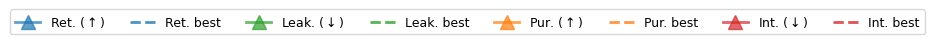

saved: plots/layer_wise_reproduce/phone_disentanglement.png


In [10]:
def plot_legend():
    # containment
    # fig_legend = plt.figure(figsize=(3, 0.5))
    # handles = []
    fig, ax = plt.subplots(1, 1, figsize=((8,0.6)), dpi=FIG_DPI)    
    ax.plot([], [], 
             marker=f"{model2markers[target_method]}", 
             color=metric2color["ret"], label=r'Ret. $(\uparrow)$', 
             markersize=MARKER_SIZE**0.5, linestyle=METHOD_LINESTYLES, alpha=MARKER_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
    ax.plot([], [],
             color=metric2color["ret"], label="Ret. best", 
             markersize=MARKER_SIZE**0.5, linestyle=BOUNDARY_LINESTYLES, alpha=BOUNDARY_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
    
    ax.plot([], [],
             marker=f"{model2markers[target_method]}",
             color=metric2color["leak"], label=r"Leak. $(\downarrow)$", 
             markersize=MARKER_SIZE**0.5, linestyle=METHOD_LINESTYLES, alpha=MARKER_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
    ax.plot([], [],
             color=metric2color["leak"], label="Leak. best", 
             markersize=MARKER_SIZE**0.5, linestyle=BOUNDARY_LINESTYLES, alpha=BOUNDARY_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
    
    
    # disentanglement
    ax.plot([], [],  
             marker=f"{model2markers[target_method]}", 
             color=metric2color["pur"], label=r"Pur. $(\uparrow)$", 
             markersize=MARKER_SIZE**0.5, linestyle=METHOD_LINESTYLES, alpha=MARKER_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
    ax.plot([], [],  
             color=metric2color["pur"], label="Pur. best", 
             markersize=MARKER_SIZE**0.5, linestyle=BOUNDARY_LINESTYLES, alpha=BOUNDARY_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
    
    ax.plot([], [], 
             marker=f"{model2markers[target_method]}",
             color=metric2color["int"], label=r"Int. $(\downarrow)$", 
             markersize=MARKER_SIZE**0.5, linestyle=METHOD_LINESTYLES, alpha=MARKER_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
    ax.plot([], [], 
             color=metric2color["int"], label="Int. best", 
             markersize=MARKER_SIZE**0.5, linestyle=BOUNDARY_LINESTYLES, alpha=BOUNDARY_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
    

    ax.legend(loc=(0, 1.1), ncol=8)          
    fig.gca().set_axis_off()
    fig.tight_layout()
    plt.savefig(f"{output_dir}/legend.png", bbox_inches ="tight", dpi=FIG_DPI)            
    plt.show()
    
    print("saved:", f"{output_dir}/phone_disentanglement.png")

plot_legend()

# Phone

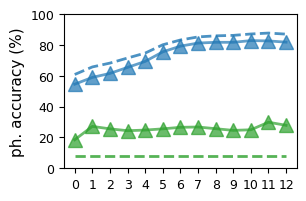

saved: plots/layer_wise_reproduce/phone_containment.png


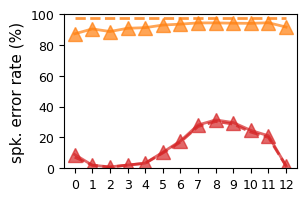

saved: plots/layer_wise_reproduce/phone_disentanglement.png


In [11]:
sel_df = layer_wise_table[layer_wise_table["concept"] == "phone"]


# containment
plt.plot(sel_df["layer"], sel_df["retention"].map(lambda x: float(x.split("/")[0])), 
         marker=f"{model2markers[target_method]}", 
         color=metric2color["ret"], label=r'Ret. $(\uparrow)$', 
         markersize=MARKER_SIZE**0.5, linestyle=METHOD_LINESTYLES, alpha=MARKER_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
plt.plot(sel_df["layer"], sel_df["retention"].map(lambda x: float(x.split("/")[1])), 
         color=metric2color["ret"], label="Ret. BEST", 
         markersize=MARKER_SIZE**0.5, linestyle=BOUNDARY_LINESTYLES, alpha=BOUNDARY_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)

plt.plot(sel_df["layer"], sel_df["leakage"].map(lambda x: float(x.split("/")[0])), 
         marker=f"{model2markers[target_method]}",
         color=metric2color["leak"], label=r"Leak. $(\downarrow)$", 
         markersize=MARKER_SIZE**0.5, linestyle=METHOD_LINESTYLES, alpha=MARKER_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
plt.plot(sel_df["layer"], sel_df["leakage"].map(lambda x: float(x.split("/")[1])),
         color=metric2color["leak"], label="Leak. BEST", 
         markersize=MARKER_SIZE**0.5, linestyle=BOUNDARY_LINESTYLES, alpha=BOUNDARY_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)

plt.ylabel("ph. accuracy (%)", fontsize=FONT_SIZE_BIG)
# plt.xlabel("layer id", fontsize=FONT_SIZE_BIG)
# plt.xlabel("layer")
plt.ylim([0, 100])
# plt.legend(loc=(0, 1.1), ncol=4)
# plt.savefig(f"{output_dir}/phone_containment_legend.png", bbox_inches ="tight", dpi=FIG_DPI)            
plt.savefig(f"{output_dir}/phone_containment.png", bbox_inches ="tight", dpi=FIG_DPI)            
plt.show()
print("saved:", f"{output_dir}/phone_containment.png")

# disentanglement
plt.plot(sel_df["layer"], sel_df["purity"].map(lambda x: float(x.split("/")[0])), 
         marker=f"{model2markers[target_method]}", 
         color=metric2color["pur"], label=r"Pur. $(\uparrow)$", 
         markersize=MARKER_SIZE**0.5, linestyle=METHOD_LINESTYLES, alpha=MARKER_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
plt.plot(sel_df["layer"], sel_df["purity"].map(lambda x: float(x.split("/")[1])), 
         color=metric2color["pur"], label="Pur. BEST", 
         markersize=MARKER_SIZE**0.5, linestyle=BOUNDARY_LINESTYLES, alpha=BOUNDARY_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)

plt.plot(sel_df["layer"], sel_df["interference"].map(lambda x: float(x.split("/")[0])), 
         marker=f"{model2markers[target_method]}",
         color=metric2color["int"], label=r"Int. $(\downarrow)$", 
         markersize=MARKER_SIZE**0.5, linestyle=METHOD_LINESTYLES, alpha=MARKER_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
plt.plot(sel_df["layer"], sel_df["interference"].map(lambda x: float(x.split("/")[1])),
         color=metric2color["int"], label="Int. BEST", 
         markersize=MARKER_SIZE**0.5, linestyle=BOUNDARY_LINESTYLES, alpha=BOUNDARY_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)


plt.ylim([0, 100])
plt.ylabel("spk. error rate (%)", fontsize=FONT_SIZE_BIG)
# plt.xlabel("layer")
# plt.legend(loc=(0, 1.1), ncol=4)
# plt.savefig(f"{output_dir}/phone_disentanglement_legend.png", bbox_inches ="tight", dpi=FIG_DPI)            
plt.savefig(f"{output_dir}/phone_disentanglement.png", bbox_inches ="tight", dpi=FIG_DPI)            
plt.show()
print("saved:", f"{output_dir}/phone_disentanglement.png")

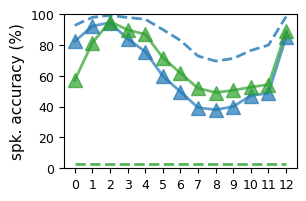

saved: plots/layer_wise_reproduce/spk_containment.png


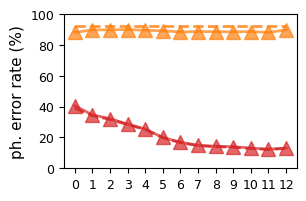

saved: plots/layer_wise_reproduce/spk_disentanglement.png


In [12]:
sel_df = layer_wise_table[layer_wise_table["concept"] == "spk"]


# containment
plt.plot(sel_df["layer"], sel_df["retention"].map(lambda x: float(x.split("/")[0])), 
         marker=f"{model2markers[target_method]}", 
         color=metric2color["ret"], label=r'Ret. $(\uparrow)$', 
         markersize=MARKER_SIZE**0.5, linestyle=METHOD_LINESTYLES, alpha=MARKER_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
plt.plot(sel_df["layer"], sel_df["retention"].map(lambda x: float(x.split("/")[1])), 
         color=metric2color["ret"], label="Ret. BEST", 
         markersize=MARKER_SIZE**0.5, linestyle=BOUNDARY_LINESTYLES, alpha=BOUNDARY_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)

plt.plot(sel_df["layer"], sel_df["leakage"].map(lambda x: float(x.split("/")[0])), 
         marker=f"{model2markers[target_method]}",
         color=metric2color["leak"], label=r"Leak. $(\downarrow)$", 
         markersize=MARKER_SIZE**0.5, linestyle=METHOD_LINESTYLES, alpha=MARKER_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
plt.plot(sel_df["layer"], sel_df["leakage"].map(lambda x: float(x.split("/")[1])),
         color=metric2color["leak"], label="Leak. BEST", 
         markersize=MARKER_SIZE**0.5, linestyle=BOUNDARY_LINESTYLES, alpha=BOUNDARY_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)

plt.ylabel("spk. accuracy (%)", fontsize=FONT_SIZE_BIG)
# plt.xlabel("layer")
plt.ylim([0, 100])
# plt.legend(loc=(0, 1.05), ncol=2)
plt.savefig(f"{output_dir}/spk_containment.png", bbox_inches ="tight", dpi=FIG_DPI)            
plt.show()
print("saved:", f"{output_dir}/spk_containment.png")

# disentanglement
plt.plot(sel_df["layer"], sel_df["purity"].map(lambda x: float(x.split("/")[0])), 
         marker=f"{model2markers[target_method]}", 
         color=metric2color["pur"], label=r"Pur. $(\uparrow)$", 
         markersize=MARKER_SIZE**0.5, linestyle=METHOD_LINESTYLES, alpha=MARKER_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
plt.plot(sel_df["layer"], sel_df["purity"].map(lambda x: float(x.split("/")[1])), 
         color=metric2color["pur"], label="Pur. BEST", 
         markersize=MARKER_SIZE**0.5, linestyle=BOUNDARY_LINESTYLES, alpha=BOUNDARY_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)

plt.plot(sel_df["layer"], sel_df["interference"].map(lambda x: float(x.split("/")[0])), 
         marker=f"{model2markers[target_method]}",
         color=metric2color["int"], label=r"Int. $(\downarrow)$", 
         markersize=MARKER_SIZE**0.5, linestyle=METHOD_LINESTYLES, alpha=MARKER_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)
plt.plot(sel_df["layer"], sel_df["interference"].map(lambda x: float(x.split("/")[1])),
         color=metric2color["int"], label="Int. BEST", 
         markersize=MARKER_SIZE**0.5, linestyle=BOUNDARY_LINESTYLES, alpha=BOUNDARY_ALPHA, linewidth=BOUNDARY_LINE_WIDTH)


plt.ylim([0, 100])
plt.ylabel("ph. error rate (%)", fontsize=FONT_SIZE_BIG)
# plt.xlabel("layer")
# plt.legend(loc=(0, 1.05), ncol=2)
plt.savefig(f"{output_dir}/spk_disentanglement.png", bbox_inches ="tight", dpi=FIG_DPI)            
plt.show()
print("saved:", f"{output_dir}/spk_disentanglement.png")